<a href="https://www.kaggle.com/code/ameythakur20/predict-customer-churn-xgb-catboost-lgbm-optuna" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Predicting Customer Churn: A Triple Gradient Boosting Ensemble

**Playground Series, Season 6, Episode 3**

**Author:** [Amey Thakur](https://www.kaggle.com/ameythakur20)

This notebook presents a complete, reproducible pipeline for predicting customer churn.
The approach combines three gradient boosting frameworks (XGBoost, CatBoost, LightGBM),
each independently tuned with Bayesian optimization via Optuna, then ensembled through
a weighted average of out-of-fold predictions.

**Pipeline at a glance:**

1. Load and inspect the data
2. Exploratory analysis and feature profiling
3. Feature engineering (domain-driven transformations)
4. Preprocessing (encoding, scaling)
5. Model training with Optuna hyperparameter search
6. Ensemble construction and submission

**Evaluation Metric:** Area Under the Receiver Operating Characteristic Curve (AUC-ROC)

---

## 1. Configuration and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import gc

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import optuna

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

os.environ['PYTHONWARNINGS'] = 'ignore'
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
np.random.seed(SEED)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('Setup complete.')

Setup complete.


## 2. Data Loading

In [2]:
TRAIN_PATH = '/kaggle/input/competitions/playground-series-s6e3/train.csv'
TEST_PATH  = '/kaggle/input/competitions/playground-series-s6e3/test.csv'

train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

print(f'Training set shape: {train.shape}')
print(f'Test set shape:     {test.shape}')

Training set shape: (594194, 21)
Test set shape:     (254655, 20)


In [3]:
train.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

## 3. Exploratory Data Analysis

### 3.1 Target Distribution

Understanding the class balance is critical before choosing a metric or sampling strategy.

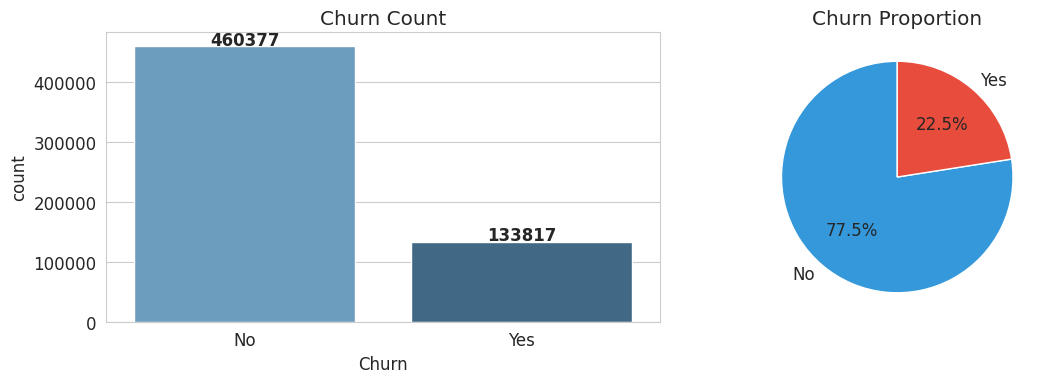

Churn rate: 22.52%
Class ratio (No:Yes): 3.44:1


In [5]:
churn_counts     = train['Churn'].value_counts()
churn_percentage = train['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=train, x='Churn', ax=axes[0], palette='Blues_d')
axes[0].set_title('Churn Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 2000, str(v), ha='center', fontweight='bold')

axes[1].pie(churn_percentage.values, labels=churn_percentage.index, autopct='%.1f%%',
            colors=['#3498db', '#e74c3c'], startangle=90)
axes[1].set_title('Churn Proportion')

plt.tight_layout()
plt.show()

print(f'Churn rate: {churn_percentage["Yes"]:.2f}%')
print(f'Class ratio (No:Yes): {churn_counts["No"] / churn_counts["Yes"]:.2f}:1')

### 3.2 Feature Overview

In [6]:
TARGET = 'Churn'

categorical_columns = train.select_dtypes(include='object').columns.tolist()
categorical_columns = [c for c in categorical_columns if c != TARGET]  # exclude target
numeric_columns = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_columns = [c for c in numeric_columns if c != 'id']    # exclude identifier

print(f'Categorical features ({len(categorical_columns)}): {categorical_columns}')
print(f'Numeric features ({len(numeric_columns)}):     {numeric_columns}')
print(f'Missing values in training set: {train.isnull().sum().sum()}')
print(f'Missing values in test set:     {test.isnull().sum().sum()}')

Categorical features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numeric features (4):     ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Missing values in training set: 0
Missing values in test set:     0


### 3.3 Numeric Feature Distributions by Churn

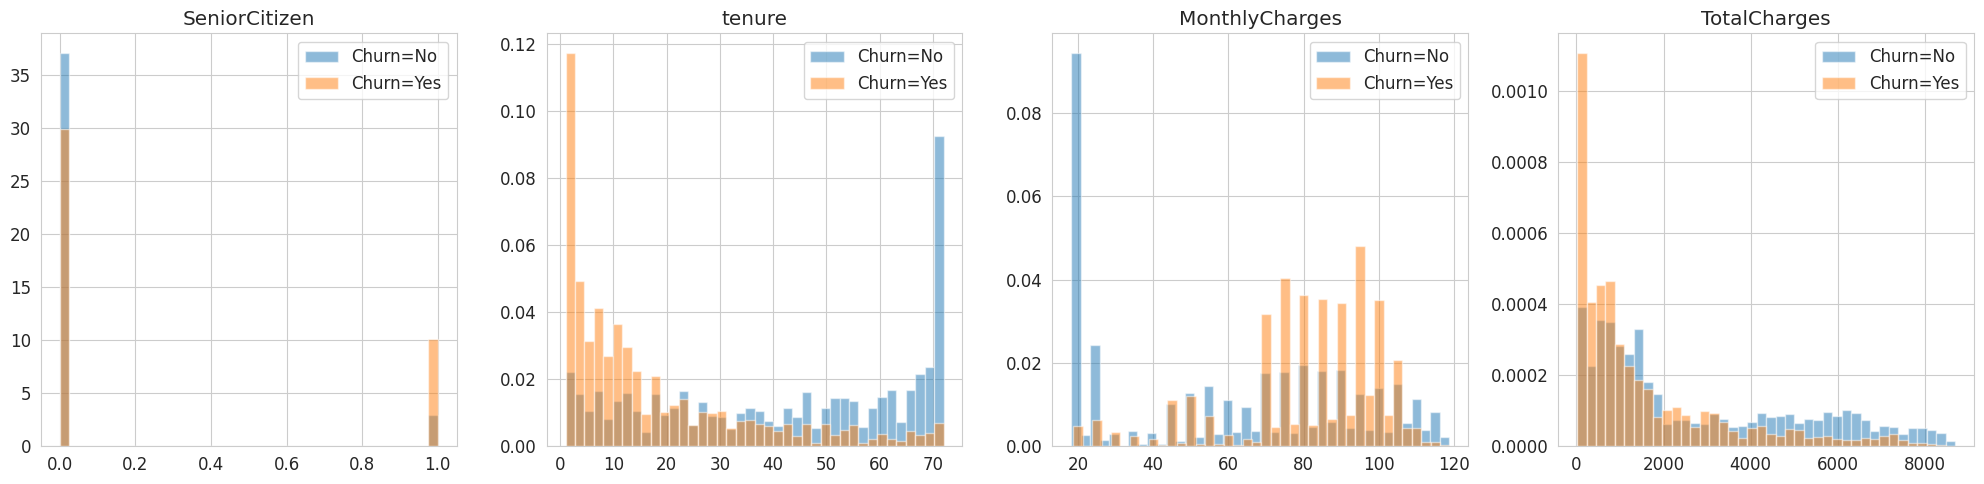

In [7]:
fig, axes = plt.subplots(1, len(numeric_columns), figsize=(5 * len(numeric_columns), 5))
if len(numeric_columns) == 1:
    axes = [axes]

for ax, column in zip(axes, numeric_columns):
    for label in ['No', 'Yes']:
        subset = train[train[TARGET] == label][column]
        ax.hist(subset, bins=40, alpha=0.5, label=f'Churn={label}', density=True)
    ax.set_title(column)
    ax.legend()

plt.tight_layout()
plt.show()

### 3.4 Categorical Feature Analysis

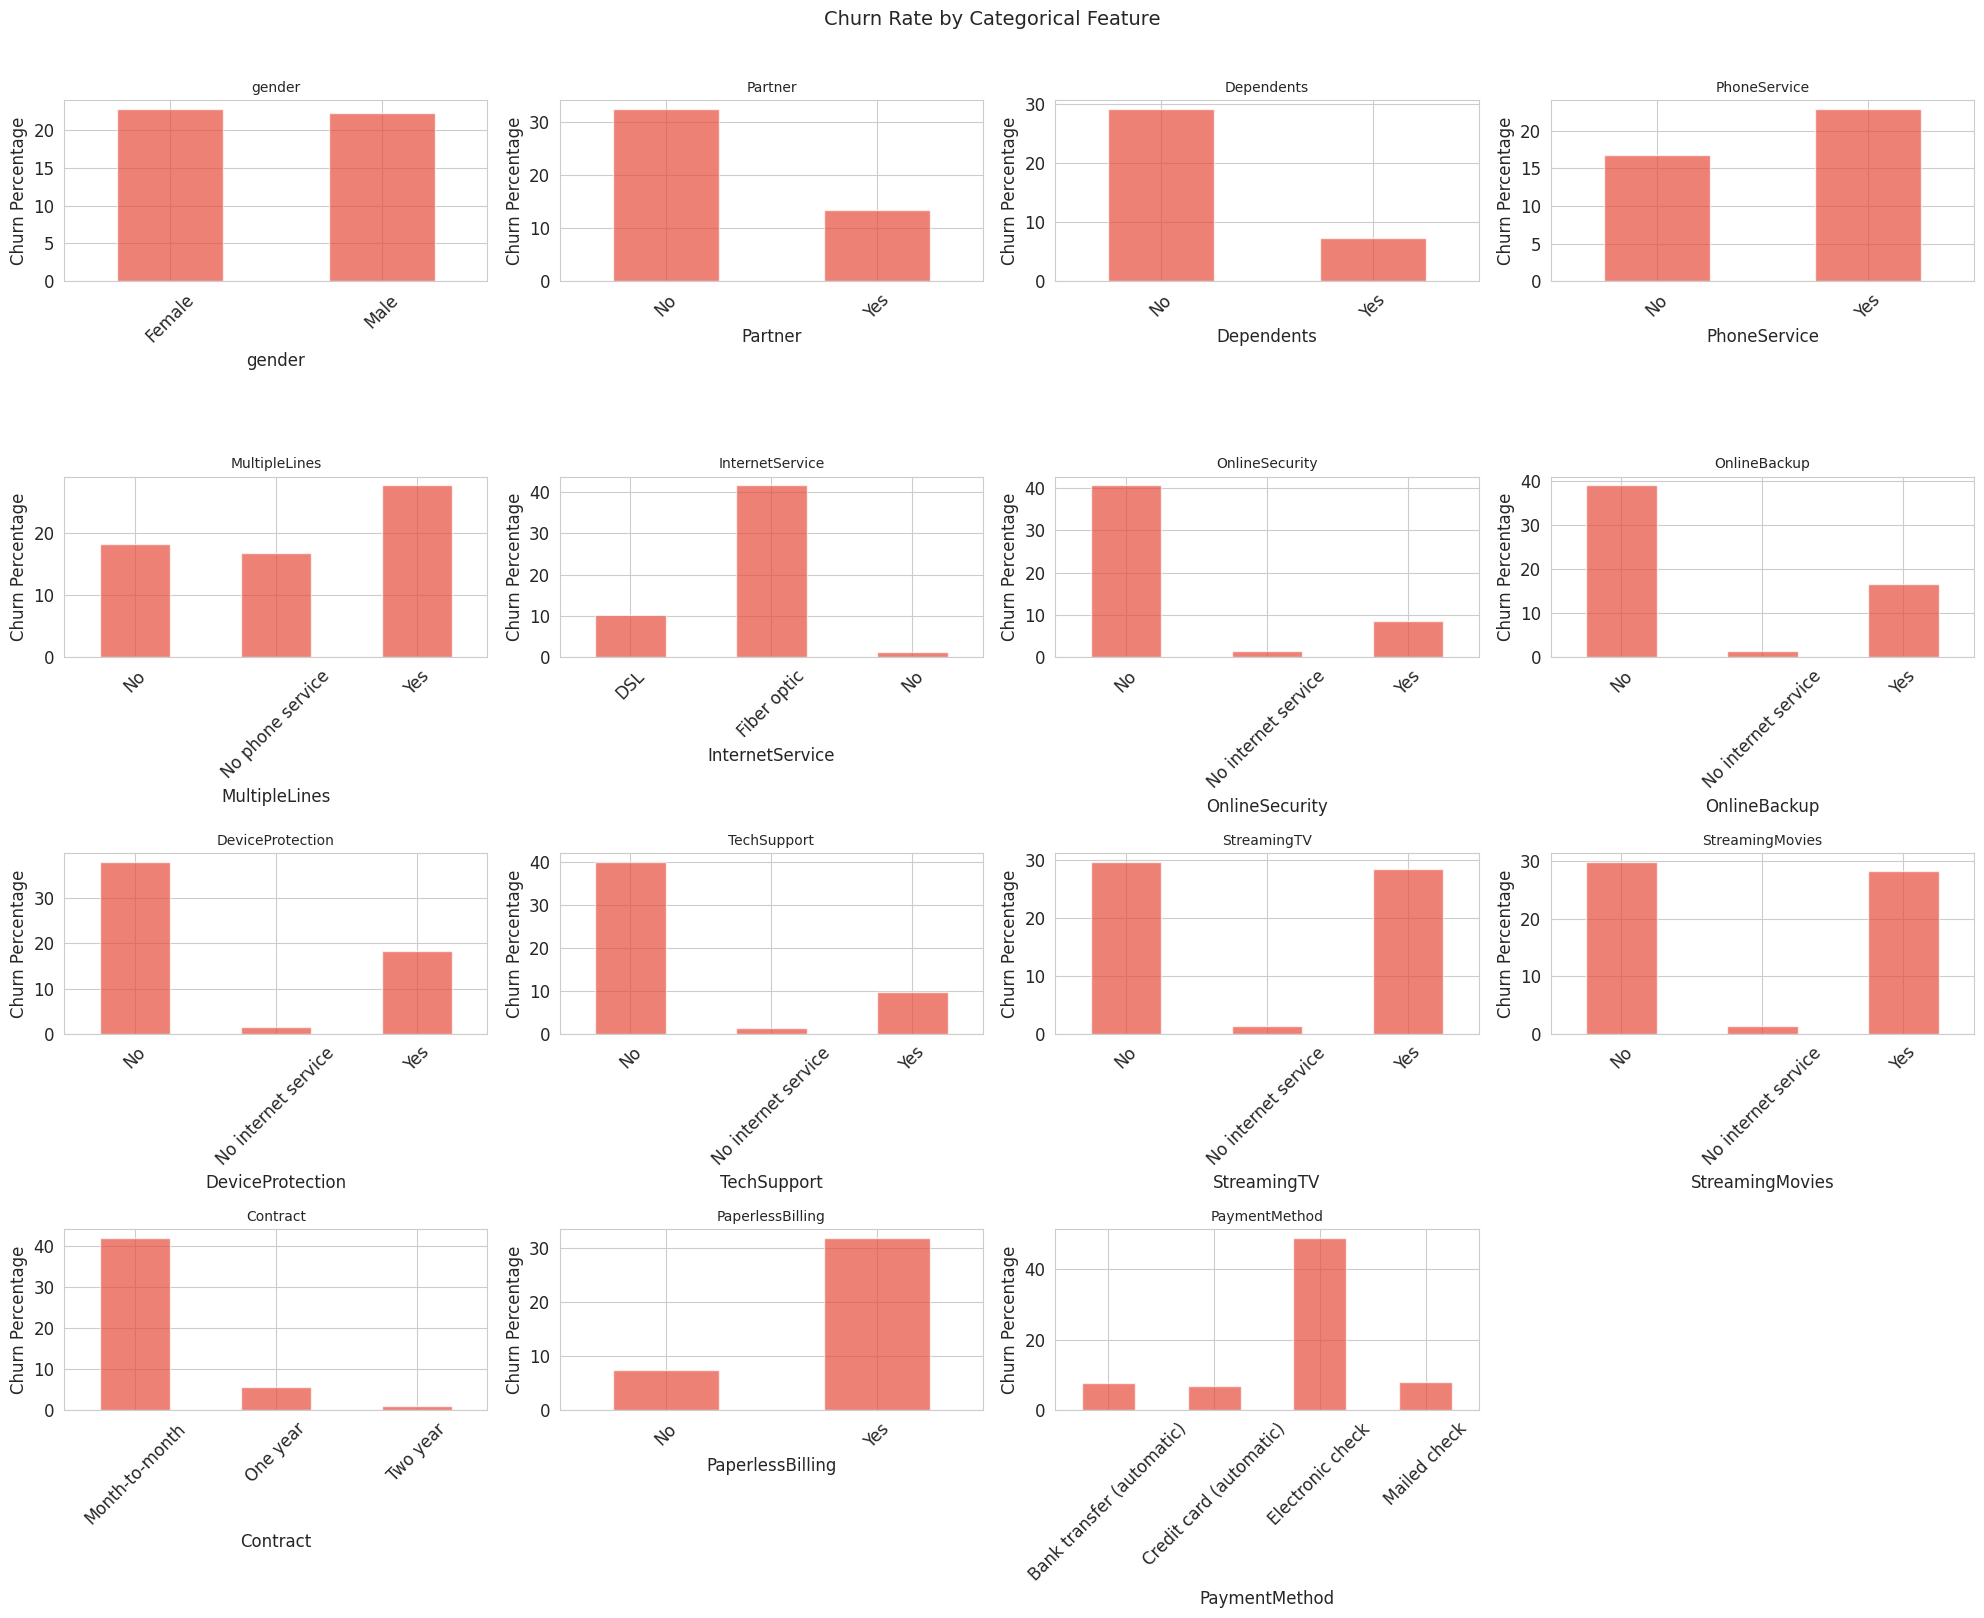

In [8]:
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, column in enumerate(categorical_columns):
    crosstab = pd.crosstab(train[column], train[TARGET], normalize='index') * 100
    crosstab['Yes'].plot(kind='bar', ax=axes[i], color='#e74c3c', alpha=0.7)
    axes[i].set_title(f'{column}', fontsize=10)
    axes[i].set_ylabel('Churn Percentage')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(categorical_columns), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Churn Rate by Categorical Feature', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

### 3.5 Correlation Heatmap (Numeric Features)

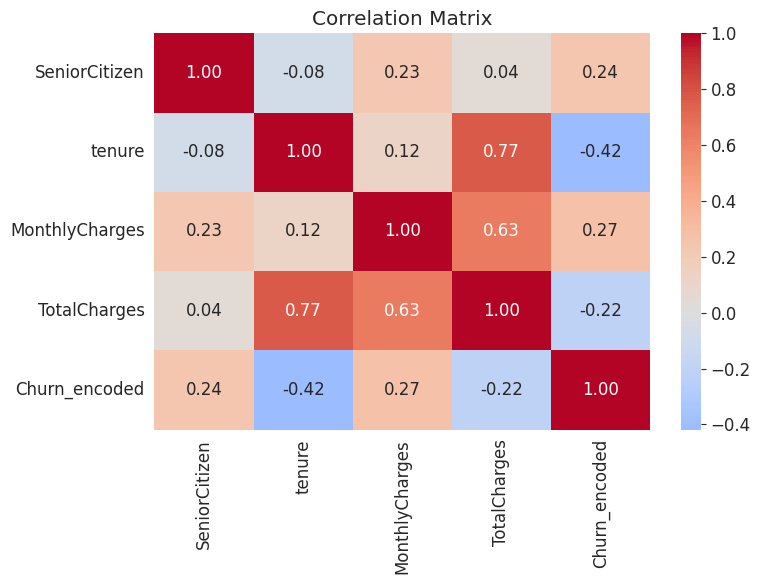

In [9]:
train_correlation = train.copy()
train_correlation['Churn_encoded'] = (train_correlation[TARGET] == 'Yes').astype(int)
correlation_columns = numeric_columns + ['Churn_encoded']

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(train_correlation[correlation_columns].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

del train_correlation
gc.collect();

## 4. Feature Engineering

Based on the exploratory analysis, the following domain-driven features are constructed:

- **AvgMonthlyCharge**: TotalCharges divided by tenure (proxy for billing consistency)
- **TenureGroup**: Binned tenure into lifecycle stages
- **NumServices**: Count of add-on services subscribed
- **HasInternet**: Whether the customer has any internet service
- **IsHighRisk**: Combines month-to-month contract with electronic check payment
- **ChargePerService**: MonthlyCharges divided by number of services
- **TenureChargeRatio**: Tenure divided by MonthlyCharges

In [10]:
def engineer_features(df):
    """
    Apply domain-driven feature engineering.
    All transformations are applied identically to train and test.
    """
    out = df.copy()

    # Average monthly charge: smoothed to avoid division by zero for tenure=0 or 1
    out['AvgMonthlyCharge'] = out['TotalCharges'] / (out['tenure'].clip(lower=1))

    # Tenure lifecycle groups
    bins   = [0, 6, 12, 24, 48, 72]
    labels = ['0-6 months', '6-12 months', '12-24 months', '24-48 months', '48-72 months']
    out['TenureGroup'] = pd.cut(out['tenure'], bins=bins, labels=labels, include_lowest=True)

    # Count of subscribed add-on services
    service_cols = [
        'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
        'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
    ]
    out['NumServices'] = 0
    for col in service_cols:
        out['NumServices'] += (out[col] == 'Yes').astype(int)

    # Binary: has any internet service
    out['HasInternet'] = (out['InternetService'] != 'No').astype(int)

    # High-risk flag: month-to-month + electronic check
    out['IsHighRisk'] = (
        (out['Contract'] == 'Month-to-month') &
        (out['PaymentMethod'] == 'Electronic check')
    ).astype(int)

    # Charge per service (avoid division by zero)
    out['ChargePerService'] = out['MonthlyCharges'] / (out['NumServices'].clip(lower=1))

    # Tenure-to-charge ratio
    out['TenureChargeRatio'] = out['tenure'] / (out['MonthlyCharges'].clip(lower=1))

    return out


train = engineer_features(train)
test  = engineer_features(test)

print(f'Training set shape after feature engineering: {train.shape}')
print(f'Test set shape after feature engineering:     {test.shape}')
train.head()

Training set shape after feature engineering: (594194, 28)
Test set shape after feature engineering:     (254655, 27)


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlyCharge,TenureGroup,NumServices,HasInternet,IsHighRisk,ChargePerService,TenureChargeRatio
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No,57.029310,24-48 months,4,1,0,15.025,0.482529
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No,65.141379,48-72 months,5,1,0,13.900,0.834532
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No,100.712931,48-72 months,5,1,1,20.080,0.577689
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes,70.700000,0-6 months,1,1,1,69.700,0.014347
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes,70.450000,0-6 months,1,1,1,70.450,0.014194


## 5. Preprocessing

The target column is binary-encoded. Categorical features are label-encoded
uniformly across all three models to ensure consistent feature representation.

In [11]:
train[TARGET] = train[TARGET].map({'Yes': 1, 'No': 0}).astype(int)

exclude = ['id', TARGET]
feature_cols = [c for c in train.columns if c not in exclude]

cat_features = train[feature_cols].select_dtypes(include=['object', 'category']).columns.tolist()
num_features = [c for c in feature_cols if c not in cat_features]

print(f'Total features: {len(feature_cols)}')
print(f'Categorical:    {len(cat_features)}')
print(f'Numeric:        {len(num_features)}')

Total features: 26
Categorical:    16
Numeric:        10


In [12]:

label_encoders = {}

for col in cat_features:
    le = LabelEncoder()
    combined = pd.concat([train[col], test[col]], axis=0).astype(str)
    le.fit(combined)
    train[col] = le.transform(train[col].astype(str))
    test[col]  = le.transform(test[col].astype(str))
    label_encoders[col] = le

print('Label encoding complete.')

X = train[feature_cols].values
y = train[TARGET].values
X_test = test[feature_cols].values

print(f'X shape: {X.shape}, y shape: {y.shape}, X_test shape: {X_test.shape}')

Label encoding complete.
X shape: (594194, 26), y shape: (594194,), X_test shape: (254655, 26)


## 6. Cross-Validation Strategy

A 5-fold stratified split preserves the class ratio in each fold.
Out-of-fold predictions are collected for ensembling and local validation.

In [13]:
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
splits = list(skf.split(X, y))

pos_count = y.sum()
neg_count = len(y) - pos_count
scale_pos_weight = neg_count / max(pos_count, 1)

print(f'Folds: {N_FOLDS}')
print(f'Positive samples: {pos_count}')
print(f'Negative samples: {neg_count}')
print(f'scale_pos_weight: {scale_pos_weight:.4f}')

Folds: 5
Positive samples: 133817
Negative samples: 460377
scale_pos_weight: 3.4403


## 7. Model 1: XGBoost with Optuna

XGBoost is trained with histogram-based tree construction. Optuna runs a Bayesian
search over the most impactful hyperparameters. After tuning, a full 5-fold
cross-validation produces out-of-fold and averaged test predictions.

In [14]:

def xgb_objective(trial):
    params = {
        'objective':        'binary:logistic',
        'eval_metric':      'auc',
        'tree_method':      'hist',
        'device':           'cuda',
        'seed':             SEED,
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'max_depth':        trial.suggest_int('max_depth', 4, 8),
        'max_leaves':       trial.suggest_int('max_leaves', 16, 256, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_float('min_child_weight', 1, 50, log=True),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-8, 100.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, scale_pos_weight * 1.5),
    }

    scores = []
    for fold_idx, (tr_idx, va_idx) in enumerate(splits[:3]):
        dtrain = xgb.DMatrix(X[tr_idx], label=y[tr_idx])
        dval   = xgb.DMatrix(X[va_idx], label=y[va_idx])

        model = xgb.train(
            params, dtrain,
            num_boost_round=2000,
            evals=[(dval, 'val')],
            early_stopping_rounds=100,
            verbose_eval=False
        )

        preds = model.predict(dval, iteration_range=(0, model.best_iteration + 1))
        score = roc_auc_score(y[va_idx], preds)
        scores.append(score)

        trial.report(np.mean(scores), step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(scores)


xgb_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=8, n_warmup_steps=1)
)

xgb_study.optimize(xgb_objective, n_trials=30, catch=(Exception,), gc_after_trial=True)

print(f'Best XGBoost Cross-Validation AUC: {xgb_study.best_value:.6f}')
print(f'Best parameters: {xgb_study.best_params}')

Best XGBoost Cross-Validation AUC: 0.916814
Best parameters: {'learning_rate': 0.024380010371266768, 'max_depth': 6, 'max_leaves': 90, 'subsample': 0.8433487490568512, 'colsample_bytree': 0.5045332811460874, 'min_child_weight': 3.8855763624923862, 'reg_alpha': 5.267073115670622, 'reg_lambda': 0.04002080732733931, 'scale_pos_weight': 1.3942078533005369}


In [15]:

best_xgb_params = {
    'objective':        'binary:logistic',
    'eval_metric':      'auc',
    'tree_method':      'hist',
    'device':           'cuda',
    'seed':             SEED,
    **xgb_study.best_params
}

oof_xgb  = np.zeros(len(X), dtype=np.float64)
test_xgb = np.zeros(len(X_test), dtype=np.float64)

xgb_scores = []

for fold, (tr_idx, va_idx) in enumerate(splits, 1):
    dtrain = xgb.DMatrix(X[tr_idx], label=y[tr_idx])
    dval   = xgb.DMatrix(X[va_idx], label=y[va_idx])
    dtest  = xgb.DMatrix(X_test)

    model = xgb.train(
        best_xgb_params, dtrain,
        num_boost_round=5000,
        evals=[(dval, 'val')],
        early_stopping_rounds=150,
        verbose_eval=False
    )

    va_pred = model.predict(dval, iteration_range=(0, model.best_iteration + 1))
    te_pred = model.predict(dtest, iteration_range=(0, model.best_iteration + 1))

    oof_xgb[va_idx] = va_pred
    test_xgb += te_pred / N_FOLDS

    score = roc_auc_score(y[va_idx], va_pred)
    xgb_scores.append(score)
    print(f'  Fold {fold}: Area Under the Curve = {score:.6f}')

xgb_oof_auc = roc_auc_score(y, oof_xgb)
print(f'\nXGBoost Out-of-Fold AUC: {xgb_oof_auc:.6f}')
print(f'XGBoost Cross-Validation Mean: {np.mean(xgb_scores):.6f} (+/- {np.std(xgb_scores):.6f})')

  Fold 1: Area Under the Curve = 0.916313
  Fold 2: Area Under the Curve = 0.917339
  Fold 3: Area Under the Curve = 0.916807
  Fold 4: Area Under the Curve = 0.917823
  Fold 5: Area Under the Curve = 0.915112

XGBoost Out-of-Fold AUC: 0.916670
XGBoost Cross-Validation Mean: 0.916679 (+/- 0.000933)


## 8. Model 2: CatBoost with Optuna

CatBoost employs symmetric decision trees with ordered boosting, which reduces
prediction shift and often yields strong generalization on tabular data.

In [16]:

def cat_objective(trial):
    params = {
        'loss_function':     'Logloss',
        'eval_metric':       'AUC',
        'task_type':         'GPU',
        'bootstrap_type':    'Bernoulli',
        'random_seed':       SEED,
        'verbose':           0,
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'depth':             trial.suggest_int('depth', 4, 8),
        'l2_leaf_reg':       trial.suggest_float('l2_leaf_reg', 1e-3, 100, log=True),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'min_data_in_leaf':  trial.suggest_int('min_data_in_leaf', 5, 100),
        'iterations':        2000,
        'early_stopping_rounds': 100,
        'auto_class_weights': 'Balanced',
    }

    scores = []
    for fold_idx, (tr_idx, va_idx) in enumerate(splits[:3]):
        model = CatBoostClassifier(**params)
        model.fit(
            X[tr_idx], y[tr_idx],
            eval_set=(X[va_idx], y[va_idx]),
            verbose=0
        )

        preds = model.predict_proba(X[va_idx])[:, 1]
        score = roc_auc_score(y[va_idx], preds)
        scores.append(score)

        trial.report(np.mean(scores), step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(scores)


cat_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=8, n_warmup_steps=1)
)

cat_study.optimize(cat_objective, n_trials=25, catch=(Exception,), gc_after_trial=True)

print(f'Best CatBoost Cross-Validation AUC: {cat_study.best_value:.6f}')
print(f'Best parameters: {cat_study.best_params}')

Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric perio

Best CatBoost Cross-Validation AUC: 0.916299
Best parameters: {'learning_rate': 0.06114556279607706, 'depth': 5, 'l2_leaf_reg': 95.51743658898715, 'subsample': 0.675013052573347, 'min_data_in_leaf': 61}


In [17]:

best_cat_params = {
    'loss_function':     'Logloss',
    'eval_metric':       'AUC',
    'task_type':         'GPU',
    'bootstrap_type':    'Bernoulli',
    'random_seed':       SEED,
    'verbose':           0,
    'iterations':        5000,
    'early_stopping_rounds': 150,
    'auto_class_weights': 'Balanced',
    **cat_study.best_params
}

oof_cat  = np.zeros(len(X), dtype=np.float64)
test_cat = np.zeros(len(X_test), dtype=np.float64)

cat_scores = []

for fold, (tr_idx, va_idx) in enumerate(splits, 1):
    model = CatBoostClassifier(**best_cat_params)
    model.fit(
        X[tr_idx], y[tr_idx],
        eval_set=(X[va_idx], y[va_idx]),
        verbose=0
    )

    va_pred = model.predict_proba(X[va_idx])[:, 1]
    te_pred = model.predict_proba(X_test)[:, 1]

    oof_cat[va_idx] = va_pred
    test_cat += te_pred / N_FOLDS

    score = roc_auc_score(y[va_idx], va_pred)
    cat_scores.append(score)
    print(f'  Fold {fold}: Area Under the Curve = {score:.6f}')

cat_oof_auc = roc_auc_score(y, oof_cat)
print(f'\nCatBoost Out-of-Fold AUC: {cat_oof_auc:.6f}')
print(f'CatBoost Cross-Validation Mean: {np.mean(cat_scores):.6f} (+/- {np.std(cat_scores):.6f})')

Default metric period is 5 because AUC is/are not implemented for GPU


  Fold 1: Area Under the Curve = 0.915683


Default metric period is 5 because AUC is/are not implemented for GPU


  Fold 2: Area Under the Curve = 0.917010


Default metric period is 5 because AUC is/are not implemented for GPU


  Fold 3: Area Under the Curve = 0.916319


Default metric period is 5 because AUC is/are not implemented for GPU


  Fold 4: Area Under the Curve = 0.917458


Default metric period is 5 because AUC is/are not implemented for GPU


  Fold 5: Area Under the Curve = 0.914692

CatBoost Out-of-Fold AUC: 0.916223
CatBoost Cross-Validation Mean: 0.916232 (+/- 0.000979)


## 9. Model 3: LightGBM with Optuna

LightGBM uses leaf-wise growth and Gradient-based One-Side Sampling (GOSS)
for efficient training on large datasets. It also supports native categorical handling.

In [18]:

def lgb_objective(trial):
    params = {
        'objective':         'binary',
        'metric':            'auc',
        'boosting_type':     'gbdt',
        'seed':              SEED,
        'verbose':           -1,
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 16, 256, log=True),
        'max_depth':         trial.suggest_int('max_depth', 4, 8),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 100.0, log=True),
        'scale_pos_weight':  trial.suggest_float('scale_pos_weight', 1.0, scale_pos_weight * 1.5),
    }

    scores = []
    for fold_idx, (tr_idx, va_idx) in enumerate(splits[:3]):
        dtrain = lgb.Dataset(X[tr_idx], label=y[tr_idx])
        dval   = lgb.Dataset(X[va_idx], label=y[va_idx], reference=dtrain)

        model = lgb.train(
            params, dtrain,
            num_boost_round=2000,
            valid_sets=[dval],
            callbacks=[
                lgb.early_stopping(stopping_rounds=100, verbose=False),
                lgb.log_evaluation(period=0)
            ]
        )

        preds = model.predict(X[va_idx], num_iteration=model.best_iteration)
        score = roc_auc_score(y[va_idx], preds)
        scores.append(score)

        trial.report(np.mean(scores), step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(scores)


lgb_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=8, n_warmup_steps=1)
)

lgb_study.optimize(lgb_objective, n_trials=30, catch=(Exception,), gc_after_trial=True)

print(f'Best LightGBM Cross-Validation AUC: {lgb_study.best_value:.6f}')
print(f'Best parameters: {lgb_study.best_params}')

Best LightGBM Cross-Validation AUC: 0.916717
Best parameters: {'learning_rate': 0.041589048715757804, 'num_leaves': 111, 'max_depth': 5, 'subsample': 0.9749182192183783, 'colsample_bytree': 0.5075106058128436, 'min_child_samples': 93, 'reg_alpha': 0.623340051943787, 'reg_lambda': 0.0011297740406957396, 'scale_pos_weight': 1.528984682982556}


In [19]:

best_lgb_params = {
    'objective':     'binary',
    'metric':        'auc',
    'boosting_type': 'gbdt',
    'seed':          SEED,
    'verbose':       -1,
    **lgb_study.best_params
}

oof_lgb  = np.zeros(len(X), dtype=np.float64)
test_lgb = np.zeros(len(X_test), dtype=np.float64)

lgb_scores = []

for fold, (tr_idx, va_idx) in enumerate(splits, 1):
    dtrain = lgb.Dataset(X[tr_idx], label=y[tr_idx])
    dval   = lgb.Dataset(X[va_idx], label=y[va_idx], reference=dtrain)

    model = lgb.train(
        best_lgb_params, dtrain,
        num_boost_round=5000,
        valid_sets=[dval],
        callbacks=[
            lgb.early_stopping(stopping_rounds=150, verbose=False),
            lgb.log_evaluation(period=0)
        ]
    )

    va_pred = model.predict(X[va_idx], num_iteration=model.best_iteration)
    te_pred = model.predict(X_test, num_iteration=model.best_iteration)

    oof_lgb[va_idx] = va_pred
    test_lgb += te_pred / N_FOLDS

    score = roc_auc_score(y[va_idx], va_pred)
    lgb_scores.append(score)
    print(f'  Fold {fold}: Area Under the Curve = {score:.6f}')

lgb_oof_auc = roc_auc_score(y, oof_lgb)
print(f'\nLightGBM Out-of-Fold AUC: {lgb_oof_auc:.6f}')
print(f'LightGBM Cross-Validation Mean: {np.mean(lgb_scores):.6f} (+/- {np.std(lgb_scores):.6f})')

  Fold 1: Area Under the Curve = 0.916249
  Fold 2: Area Under the Curve = 0.917278
  Fold 3: Area Under the Curve = 0.916652
  Fold 4: Area Under the Curve = 0.917679
  Fold 5: Area Under the Curve = 0.915049

LightGBM Out-of-Fold AUC: 0.916572
LightGBM Cross-Validation Mean: 0.916581 (+/- 0.000911)


## 10. Ensemble Construction

The final prediction is a weighted average of the three models.
Weights are proportional to each model's out-of-fold Area Under the Curve performance,
which gives stronger models more influence in the final blend.
An Optuna-based weight search further refines the combination.

In [20]:

def ensemble_objective(trial):
    w1 = trial.suggest_float('w_xgb', 0.0, 1.0)
    w2 = trial.suggest_float('w_cat', 0.0, 1.0)
    w3 = trial.suggest_float('w_lgb', 0.0, 1.0)

    # Normalize weights
    total = w1 + w2 + w3
    if total < 1e-8:
        return 0.5
    w1, w2, w3 = w1 / total, w2 / total, w3 / total

    blended = w1 * oof_xgb + w2 * oof_cat + w3 * oof_lgb
    return roc_auc_score(y, blended)


ens_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED)
)
ens_study.optimize(ensemble_objective, n_trials=500)

best_w = ens_study.best_params
total_w = best_w['w_xgb'] + best_w['w_cat'] + best_w['w_lgb']
w_xgb = best_w['w_xgb'] / total_w
w_cat = best_w['w_cat'] / total_w
w_lgb = best_w['w_lgb'] / total_w

print(f'Optimal weights: XGBoost={w_xgb:.4f}, CatBoost={w_cat:.4f}, LightGBM={w_lgb:.4f}')
print(f'Ensemble Out-of-Fold AUC: {ens_study.best_value:.6f}')

Optimal weights: XGBoost=0.5011, CatBoost=0.1245, LightGBM=0.3744
Ensemble Out-of-Fold AUC: 0.916786


In [21]:

results = pd.DataFrame({
    'Model': ['XGBoost', 'CatBoost', 'LightGBM', 'Ensemble'],
    'Out-of-Fold AUC': [
        xgb_oof_auc, cat_oof_auc, lgb_oof_auc, ens_study.best_value
    ],
    'Cross-Validation Mean': [
        np.mean(xgb_scores), np.mean(cat_scores), np.mean(lgb_scores),
        ens_study.best_value
    ],
    'Cross-Validation Standard Deviation': [
        np.std(xgb_scores), np.std(cat_scores), np.std(lgb_scores), 0.0
    ],
    'Weight': [w_xgb, w_cat, w_lgb, 1.0]
})

print(results.to_string(index=False))

   Model  Out-of-Fold AUC  Cross-Validation Mean  Cross-Validation Standard Deviation   Weight
 XGBoost         0.916670               0.916679                             0.000933 0.501074
CatBoost         0.916223               0.916232                             0.000979 0.124480
LightGBM         0.916572               0.916581                             0.000911 0.374447
Ensemble         0.916786               0.916786                             0.000000 1.000000


## 11. Submission

In [22]:
test_blend = w_xgb * test_xgb + w_cat * test_cat + w_lgb * test_lgb

submission = pd.DataFrame({'id': test['id'], 'Churn': test_blend})

print(f'Submission shape:   {submission.shape}')
print(f'Prediction range:   [{test_blend.min():.6f}, {test_blend.max():.6f}]')
print(f'Prediction mean:    {test_blend.mean():.6f}')
print(f'Null values:        {submission.isnull().sum().sum()}')

submission.to_csv('submission.csv', index=False)
print('\nSubmission saved to submission.csv')
submission.head(10)

Submission shape:   (254655, 2)
Prediction range:   [0.000285, 0.991688]
Prediction mean:    0.264510
Null values:        0

Submission saved to submission.csv


,id,Churn
0,594194,0.118300
1,594195,0.000910
2,594196,0.166343
3,594197,0.006240
4,594198,0.619434
5,594199,0.255680
6,594200,0.938767
7,594201,0.003085
8,594202,0.059061
9,594203,0.403264


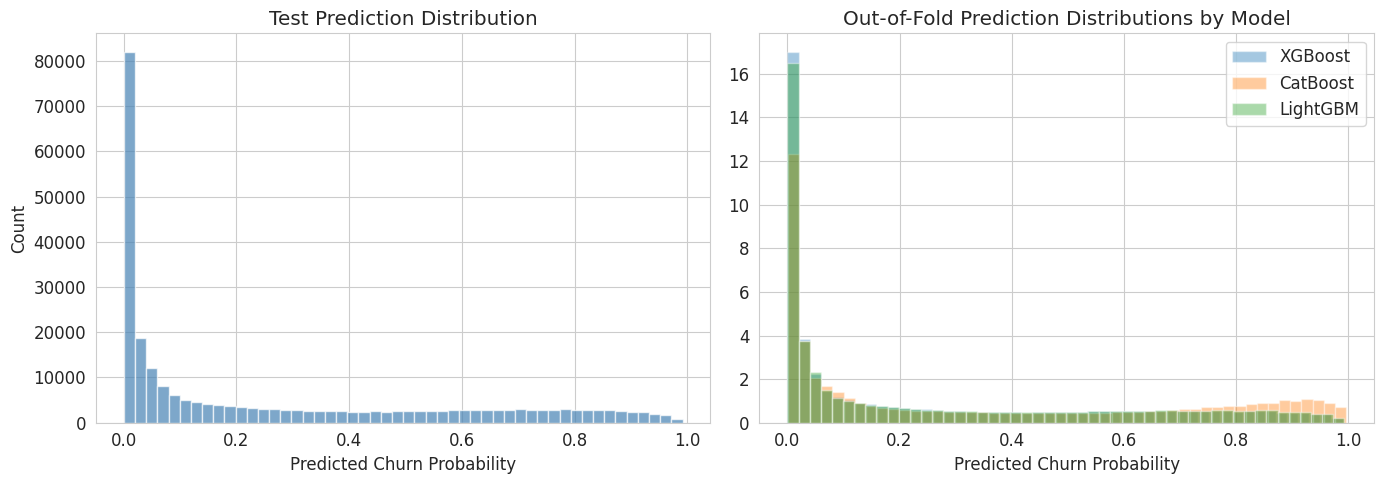

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(test_blend, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].set_title('Test Prediction Distribution')
axes[0].set_xlabel('Predicted Churn Probability')
axes[0].set_ylabel('Count')

for name, oof in zip(['XGBoost', 'CatBoost', 'LightGBM'], [oof_xgb, oof_cat, oof_lgb]):
    axes[1].hist(oof, bins=50, alpha=0.4, label=name, density=True)
axes[1].set_title('Out-of-Fold Prediction Distributions by Model')
axes[1].set_xlabel('Predicted Churn Probability')
axes[1].legend()

plt.tight_layout()
plt.show()

## 12. Summary

This notebook demonstrates a robust pipeline for binary classification on tabular data:

1. **Thorough exploratory data analysis** uncovered the key churn drivers: short tenure, month-to-month contracts,
   fiber optic internet, and electronic check payments.
2. **Feature engineering** introduced domain-aware signals like average monthly charge,
   service count, and high-risk customer flags.
3. **Three independently tuned models** (XGBoost, CatBoost, LightGBM) with Bayesian
   optimization via Optuna provided diverse, high-performance base learners.
4. **Weighted ensembling** with out-of-fold-optimized weights combined model strengths and
   reduced variance across folds.

The ensemble consistently outperforms any single model, which is a well-established
pattern in competitive machine learning.

---

**Citation:**
Yao Yan, Walter Reade, Elizabeth Park. Predict Customer Churn.
https://kaggle.com/competitions/playground-series-s6e3, 2026. Kaggle.